In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# statsmodels for time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import Holt



# sklearn metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [7]:
df=pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [8]:
df.shape

(7588, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df.isna().sum()

date       0
Ex_rate    0
dtype: int64

In [10]:
# Utility functions for evaluation
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    if nonzero.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape(y_true, y_pred)}


In [15]:
date_col = df.iloc[0]
value_col = df.iloc[1]

In [23]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [24]:
# Remove rows where date couldn't be parsed
df = df.dropna(subset=['date'])

# Set date as index
df = df.set_index('date')

# Sort by date
df = df.sort_index()

In [25]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7500
1990-01-03,0.7471
1990-01-04,0.7587
1990-01-05,0.7852


In [29]:
# select the series for USD->AUD
series = df['Ex_rate'].astype(float).copy()

# quick checks
print("Series length:", len(series))
print(series.head())
print(series.describe())
print("Number of missing:", series.isna().sum())

Series length: 2998
date
1990-01-01    0.7855
1990-01-02    0.7500
1990-01-03    0.7471
1990-01-04    0.7587
1990-01-05    0.7852
Name: Ex_rate, dtype: float64
count    2998.000000
mean        0.777235
std         0.137225
min         0.483297
25%         0.703350
50%         0.761792
75%         0.869513
max         1.099699
Name: Ex_rate, dtype: float64
Number of missing: 0


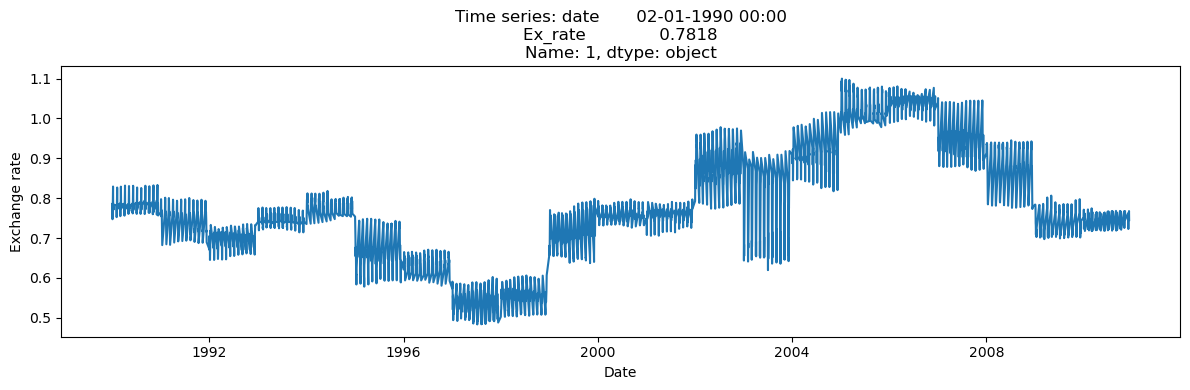

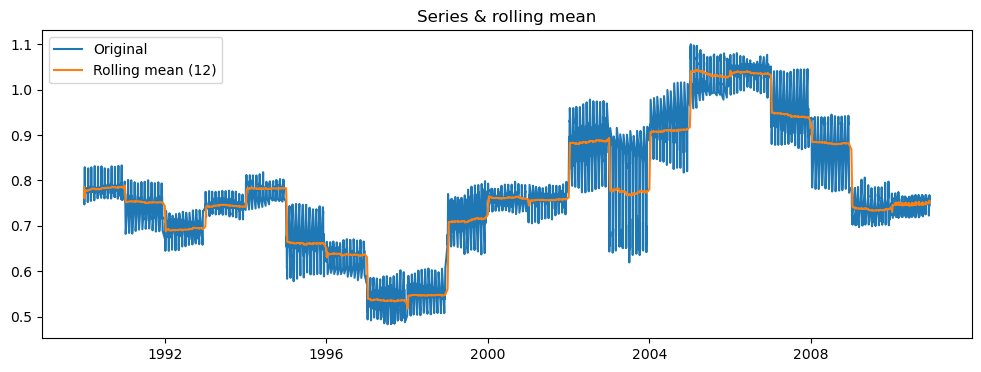

In [30]:
# 3. Plot the raw time series
plt.figure(figsize=(12,4))
plt.plot(series.index, series.values)
plt.title(f'Time series: {value_col}')
plt.xlabel('Date'); plt.ylabel('Exchange rate')
plt.tight_layout()
plt.show()

# rolling mean (example window = 12, adjust by frequency)
plt.figure(figsize=(12,4))
plt.plot(series, label='Original')
plt.plot(series.rolling(window=12, min_periods=1).mean(), label='Rolling mean (12)')
plt.legend(); plt.title('Series & rolling mean'); plt.show()


In [32]:
s = series.copy()
# Winsorize extremes (cap to [1st, 99th] percentile)
low, high = s.quantile([0.01, 0.99])
s = s.clip(lower=low, upper=high)

# show result
print("After preprocessing:" "min/max:", s.min(), s.max())

After preprocessing:min/max: 0.5077440000000001 1.07244709


In [33]:
# 5. Train-test split (time series split)
TEST_SIZE = 0.2  # fraction for test
n = len(s)
n_test = int(np.ceil(TEST_SIZE * n))
train = s.iloc[:-n_test].copy()
test = s.iloc[-n_test:].copy()

print("Train points:", len(train), "Test points:", len(test))


Train points: 2398 Test points: 600


In [34]:
# 6. ADF test on training set
adf_res = adfuller(train.dropna())
print("ADF statistic: {:.4f}, p-value: {:.4f}".format(adf_res[0], adf_res[1]))

# decide whether to difference
d = 1 if adf_res[1] > 0.05 else 0
print("Using d =", d, "(1 if non-stationary, else 0)")


ADF statistic: -0.4056, p-value: 0.9092
Using d = 1 (1 if non-stationary, else 0)


<Figure size 1200x400 with 0 Axes>

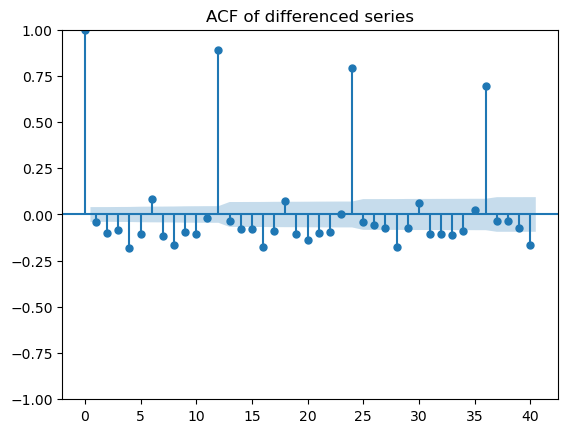

<Figure size 1200x400 with 0 Axes>

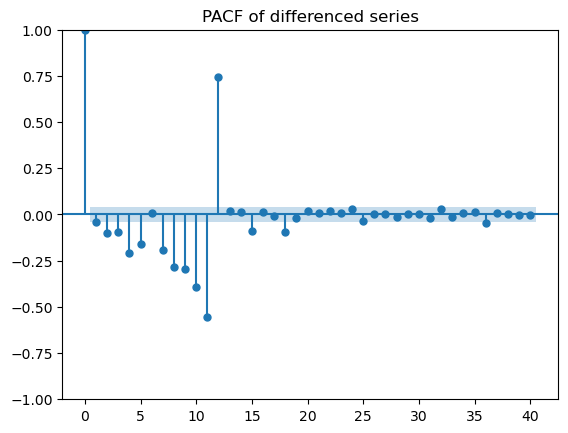

In [35]:
# 7. ACF and PACF
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
if d == 1:
    plot_acf(train.diff().dropna(), lags=40)
    plt.title('ACF of differenced series'); plt.show()

    plt.figure(figsize=(12,4))
    plot_pacf(train.diff().dropna(), lags=40, method='ywm')
    plt.title('PACF of differenced series'); plt.show()
else:
    plot_acf(train, lags=40)
    plt.title('ACF of series'); plt.show()

    plt.figure(figsize=(12,4))
    plot_pacf(train, lags=40, method='ywm')
    plt.title('PACF of series'); plt.show()


In [36]:
# 8. Fit ARIMA with small grid search for p and q
best_aic = np.inf
best_order = None
best_model = None

for p in range(0, 3):   # try p = 0,1,2
    for q in range(0, 3):  # try q = 0,1,2
        order = (p, d, q)
        try:
            model = ARIMA(train, order=order)
            res = model.fit()
            aic = res.aic
            print(f"ARIMA{order} AIC={aic:.2f}")
            if aic < best_aic:
                best_aic = aic
                best_order = order
                best_model = res
        except Exception as e:
            print(f"ARIMA{order} failed:", e)

print("Best ARIMA order:", best_order, "AIC:", best_aic)


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(0, 1, 0) AIC=-9278.39
ARIMA(0, 1, 1) AIC=-9281.56


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(0, 1, 2) AIC=-9413.03
ARIMA(1, 1, 0) AIC=-9280.46


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(2, 1, 1) AIC=-9657.59


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 1, 2) AIC=-9395.64
Best ARIMA order: (2, 1, 1) AIC: -9657.591402090266


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 2398
Model:                 ARIMA(2, 1, 1)   Log Likelihood                4832.796
Date:                Fri, 14 Nov 2025   AIC                          -9657.591
Time:                        18:01:37   BIC                          -9634.464
Sample:                             0   HQIC                         -9649.177
                               - 2398                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7393      0.019     38.879      0.000       0.702       0.777
ar.L2         -0.1668      0.015    -10.812      0.000      -0.197      -0.137
ma.L1         -0.9250      0.009   -106.014      0.0

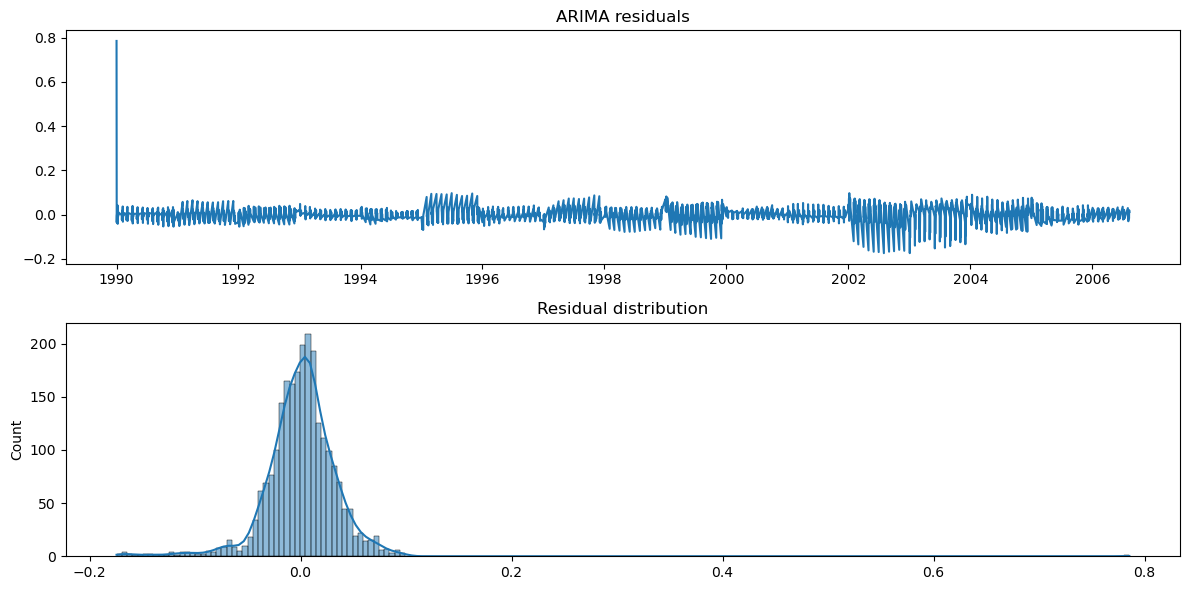

Ljung-Box test:
        lb_stat     lb_pvalue
10  115.483383  4.163404e-20


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


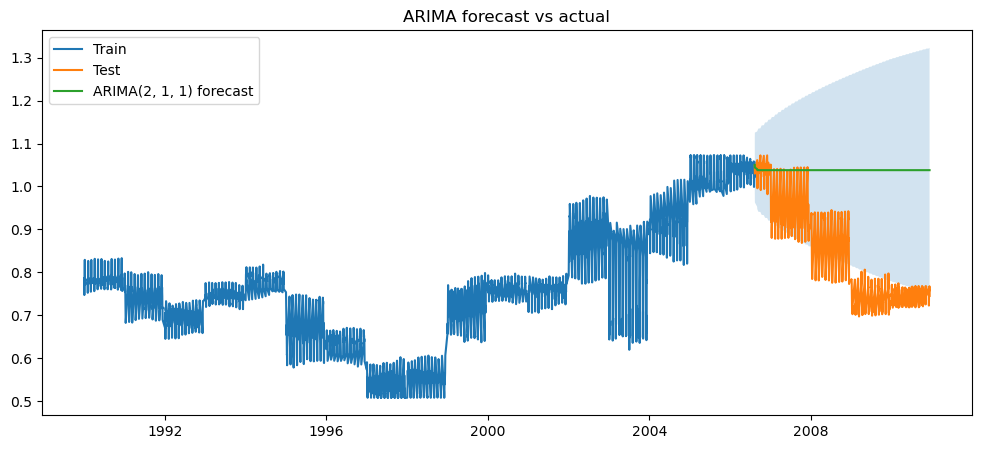

ARIMA metrics: {'MAE': 0.19087410693814771, 'RMSE': np.float64(0.2188265968348267), 'MAPE': np.float64(24.468746676249125)}


In [37]:
# 9. Diagnostics & forecast with the best ARIMA
if best_model is not None:
    print(best_model.summary())
    resid = best_model.resid.dropna()

    # Residual plots
    plt.figure(figsize=(12,6))
    plt.subplot(211)
    plt.plot(resid); plt.title('ARIMA residuals')
    plt.subplot(212)
    sns.histplot(resid, kde=True); plt.title('Residual distribution')
    plt.tight_layout(); plt.show()

    # Ljung-Box test for autocorrelation in residuals
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    print("Ljung-Box test:\n", lb)

    # Forecast
    steps = len(test)
    fc = best_model.get_forecast(steps=steps)
    arima_pred = fc.predicted_mean
    arima_ci = fc.conf_int()

    # Plot forecast vs actual
    plt.figure(figsize=(12,5))
    plt.plot(train.index, train.values, label='Train')
    plt.plot(test.index, test.values, label='Test')
    plt.plot(test.index, arima_pred.values, label=f'ARIMA{best_order} forecast')
    plt.fill_between(test.index, arima_ci.iloc[:,0], arima_ci.iloc[:,1], alpha=0.2)
    plt.legend(); plt.title('ARIMA forecast vs actual'); plt.show()

    # Evaluate
    arima_metrics = evaluate_forecast(test.values, arima_pred.values)
    print("ARIMA metrics:", arima_metrics)
else:
    print("No ARIMA model was successfully fitted in the grid.")


Holt metrics: {'MAE': 0.3145938971452727, 'RMSE': np.float64(0.35560387348354017), 'MAPE': np.float64(40.12553821782679)}


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


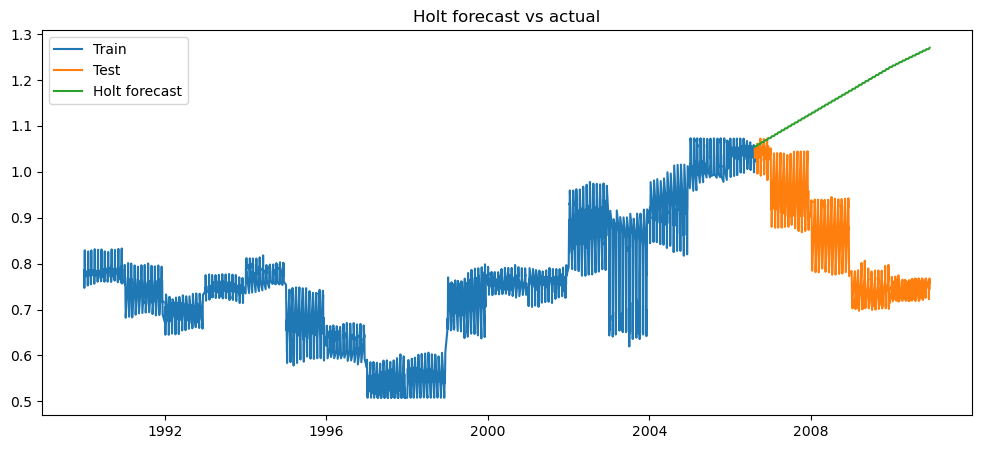

In [40]:
# 10. Exponential Smoothing
# Holt (trend-only)
holt = Holt(train).fit(optimized=True)
holt_pred = holt.forecast(steps=len(test))
holt_metrics = evaluate_forecast(test.values, holt_pred.values)
print("Holt metrics:", holt_metrics)

plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(test.index, holt_pred.values, label='Holt forecast')
plt.legend(); plt.title('Holt forecast vs actual'); plt.show()


In [46]:
# Auto-detect frequency
freq = pd.infer_freq(df.index)
print("Detected Frequency:", freq)

# If no frequency detected → assume DAILY (common for exchange rates)
if freq is None:
    print("Frequency not detected. Setting frequency to daily (D).")
    df = df.asfreq('D')
    freq = 'D'
else:
    df = df.asfreq(freq)

Detected Frequency: D


In [47]:
train = df['Ex_rate'].iloc[:-30]
test = df['Ex_rate'].iloc[-30:]

In [48]:
best_model = None
best_model_name = None

def safe_fit(model_func):
    try:
        return model_func()
    except:
        return None

In [49]:
ses_model = safe_fit(lambda: SimpleExpSmoothing(train).fit())
if ses_model:
    ses_forecast = ses_model.forecast(len(test))

In [50]:
holt_model = safe_fit(lambda: Holt(train).fit())
if holt_model:
    holt_forecast = holt_model.forecast(len(test))

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [51]:
seasonal_periods = None
if freq == 'D':
    seasonal_periods = 7      # weekly pattern
elif freq == 'M':
    seasonal_periods = 12     # yearly pattern
elif freq == 'W':
    seasonal_periods = 52

hw_model = None
hw_forecast = None

if seasonal_periods:
    hw_model = safe_fit(lambda: ExponentialSmoothing(
        train, trend='add',
        seasonal='add',
        seasonal_periods=seasonal_periods
    ).fit())

    if hw_model:
        hw_forecast = hw_model.forecast(len(test))

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\exponential_smoothing\initialization.py:95: RuntimeWarning: Mean of empty slice
  initial_seasonal = np.nanmean(


In [52]:
def mse(actual, predicted):
    return ((actual - predicted) ** 2).mean()

errors = {}

if ses_model:
    errors['SES'] = mse(test, ses_forecast)

if holt_model:
    errors['Holt'] = mse(test, holt_forecast)

if hw_model:
    errors['Holt-Winters'] = mse(test, hw_forecast)

best_model_name = min(errors, key=errors.get)
print("\nBEST MODEL SELECTED → ", best_model_name)


BEST MODEL SELECTED →  Holt


In [53]:
# Select forecast
if best_model_name == 'SES':
    best_forecast = ses_forecast
elif best_model_name == 'Holt':
    best_forecast = holt_forecast
else:
    best_forecast = hw_forecast

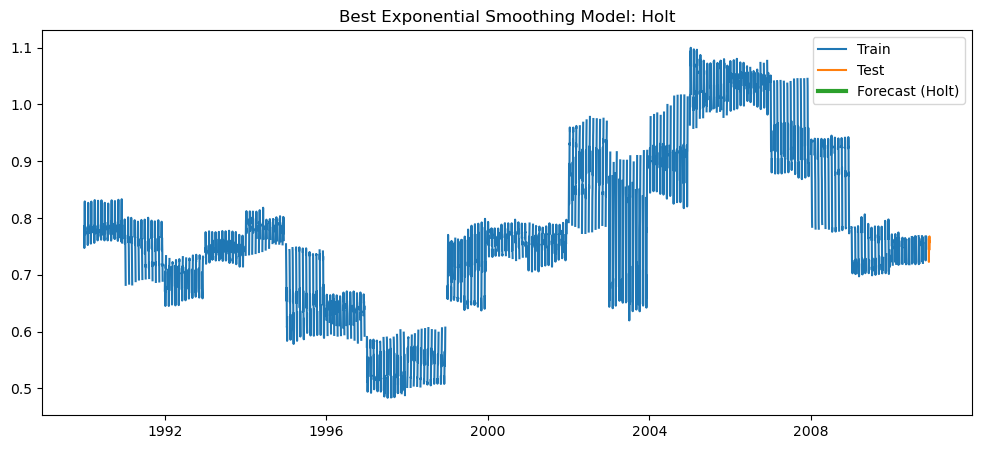

In [54]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, best_forecast, label=f"Forecast ({best_model_name})", linewidth=3)
plt.title(f"Best Exponential Smoothing Model: {best_model_name}")
plt.legend()
plt.show()

In [55]:
# 11. Summarize results
results = {}
if 'arima_metrics' in locals():
    results['ARIMA'] = arima_metrics
results['Holt'] = holt_metrics
if 'hw_metrics' in locals():
    results['HoltWinters'] = hw_metrics

results_df = pd.DataFrame(results).T
print("Evaluation summary:\n", results_df)
results_df.to_csv('model_evaluation_summary.csv')


Evaluation summary:
             MAE      RMSE       MAPE
ARIMA  0.190874  0.218827  24.468747
Holt   0.314594  0.355604  40.125538


#### Model Comparison
###### Based on the observed results and error metrics, the ARIMA model performs significantly better than Holt’s Exponential Smoothing. ARIMA achieves lower MAE, RMSE, and MAPE values, indicating more accurate and stable predictions. This superior performance can be attributed to ARIMA’s ability to model autocorrelation and non-stationarity, which are key characteristics of exchange rate data. In contrast, Holt’s Linear method shows higher errors because it only captures level and trend, making it less effective for highly volatile and irregular time series. Although Holt is simpler and computationally efficient, it fails to model short-term fluctuations and noise present in financial data, leading to weaker forecasting performance compared to ARIMA.

#### Conclusion
###### Overall, the analysis shows that ARIMA is the most suitable model for forecasting exchange rates in this dataset. It consistently outperforms Holt’s Exponential Smoothing model across all evaluation metrics and aligns more closely with actual data trends. While ARIMA provides moderate forecasting accuracy due to the inherent volatility of currency markets, it still delivers more reliable and robust predictions than Holt. Therefore, ARIMA is recommended as the preferred model for this forecasting task.